# Reproduced with ERA5-Land: Generating (CMIP6) future droughts

This notebook is used to predict future discharge values for the Loire river at Blois. For these prediction, different climate scenarios are used: SSP126, SSP2455 and SSP585. These discharge values are then analysed using the drought analyser (Drought_analyser.ipynb) to assess the difference between past and future.

**This is an addition to Ischas work, to test reproducibility and new ERA5-Land data**

### 1. Importing general python modules

In [1]:
# general python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import pandas as pd
import seaborn as sns

#niceties
from rich import print

# Needed
from ipywidgets import IntProgress
from IPython.display import display
from scipy.stats import qmc
from sklearn.metrics import mean_squared_error
from scipy.stats import wasserstein_distance
from statsmodels.distributions.empirical_distribution import ECDF

In [2]:
# general eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [3]:
# import drought analyser function
%run Drought_analyser.ipynb

### 2. Defining experiment data and paths 

In this chapter all the variables are defined for the chosen basin. Also the loading and generating path are defined for the forcings and model.

In [4]:
# name of the catchment
basin_name = "FR003882"

# defining dates for calibration
historical_start_date = "1941-01-01"
historical_end_date = "2014-12-31"
future_start_data = "2026-01-01"
future_end_data = "2099-12-31"

# defining path for catchment shape file
station_shp = Path.cwd() / "estreams_cb_FR003882.shp"

# defining destination path for ERA5 data
forcing_path_CMIP = Path.home() / "forcing" / "loire_river" / "CMIP"
forcing_path_CMIP.mkdir(exist_ok=True, parents=True)

# model HBV destination path
model_path_HBV = Path.home() / "tmp" / "HBV_model" / "CMIP"
model_path_HBV.mkdir(exist_ok=True, parents=True)

gdf = gpd.read_file("estreams_cb_FR003882.shp")
gdf = gdf.to_crs(epsg=2154)
gdf["area_km2"] = gdf.geometry.area / 1e6  
basin_area = gdf["area_km2"].sum()

In [5]:
# ADDED (new cell)
# defining destination path for ERA5 data
forcing_path_ERA5 = Path.home() / "forcing" / "loire_river" / "ERA5-90-19"
forcing_path_ERA5.mkdir(exist_ok=True, parents=True)

# era5-land
forcing_path_ERA5_land = Path.home() / "forcing" / "loire_river" / "ERA5_land-90-19"
forcing_path_ERA5_land.mkdir(exist_ok=True, parents=True)

### 3. Load generated CMIP forcings

The CMIP6 data can be generated using CMIP_forcing. If the is already generated, it can be loaded using option 2.

In [6]:
try:
    # Load historical data
    historic_location = forcing_path_CMIP / "Historical" / "work" / "diagnostic" / "script" 
    HIST = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historic_location)
except:
    cmip_historical =  {
            "dataset": 'MPI-ESM1-2-HR',
            "project": 'CMIP6',
            "grid": "gn",
            "exp": "historical",
            "ensemble": 'r1i1p1f1',
        }
    HIST = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
       dataset=cmip_historical,
       start_time=historical_start_date+"T00:00:00Z",
       end_time=historical_end_date+"T00:00:00Z",
       shape=station_shp,
       directory=forcing_path_CMIP / "Historical",
    )

In [7]:
try:
    # Load SSP126 data
    ssp126_location = forcing_path_CMIP / "SSP126_2699" / "work" / "diagnostic" / "script"
    ssp126_location.mkdir(exist_ok=True, parents=True)
    SSP126 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp126_location)
except:
    cmip_dataset =  {
       'project': 'CMIP6',
       'activity': 'ScenarioMIP',
       'exp': 'ssp126',
       'mip': 'day',
       'dataset': 'MPI-ESM1-2-HR',
       'ensemble': 'r1i1p1f1',
       'institute': 'DKRZ',
       'grid': 'gn'
    }
    SSP126 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
       dataset=cmip_dataset,
       start_time=future_start_data+"T00:00:00Z",
       end_time=future_end_data+"T00:00:00Z",
       shape=station_shp,
       directory=forcing_path_CMIP / "SSP126_2699",
    )
    
try:
    # Load SSP245 data
    ssp245_location = forcing_path_CMIP / "SSP245_2699" / "work" / "diagnostic" / "script" 
    ssp245_location.mkdir(exist_ok=True, parents=True)
    SSP245 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp245_location)
except:
    cmip_dataset =  {
       'project': 'CMIP6',
       'activity': 'ScenarioMIP',
       'exp': 'ssp245',
       'mip': 'day',
       'dataset': 'MPI-ESM1-2-HR',
       'ensemble': 'r1i1p1f1',
       'institute': 'DKRZ',
       'grid': 'gn'
    }
    SSP245 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
       dataset=cmip_dataset,
       start_time=future_start_data+"T00:00:00Z",
       end_time=future_end_data+"T00:00:00Z",
       shape=station_shp,
       directory=forcing_path_CMIP / "SSP245_2699",
    )

try:
    # Load SSP585 data
    ssp585_location = forcing_path_CMIP / "SSP585_2699" / "work" / "diagnostic" / "script" 
    ssp585_location.mkdir(exist_ok=True, parents=True)
    SSP585 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp585_location)
except:
    cmip_dataset =  {
       'project': 'CMIP6',
       'activity': 'ScenarioMIP',
       'exp': 'ssp585',
       'mip': 'day',
       'dataset': 'MPI-ESM1-2-HR',
       'ensemble': 'r1i1p1f1',
       'institute': 'DKRZ',
       'grid': 'gn'
    }
    SSP585 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
       dataset=cmip_dataset,
       start_time=future_start_data+"T00:00:00Z",
       end_time=future_end_data+"T00:00:00Z",
       shape=station_shp,
       directory=forcing_path_CMIP / "SSP585_2699",
    )
    

In [8]:
# ADDED (new cell)
# Load reanalysis forcings (ERA5 and ERA5-Land, 1990-2019)
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

load_location = forcing_path_ERA5_land / "work" / "diagnostic" / "script"
ERA5_forcing_land = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

### 4. Setting up the model (HBV)

The parameters for the HBV are calibrated in HBV_calibration.ipynb. These calibrated parameters are defined below. The starting values for model stores are manually adjust using a 'spin-up' method.

In [9]:
# Good parameters distribution calibration (N = 1000)
params = np.load('best_params_era5_n1000.npy')
params_land = np.load('best_params_era5_land_n1000.npy')

# # Run your own or our calibration
# params = np.load('best_params_era5.npy')
# params_land = np.load('best_params_era5_land.npy')

# Starting values for model storages
#                Si,    Su,  Sf,    Ss,  Sp
s_0 = np.array([5.3, 249.8, 2.4, 372.5, 2.9])

### 5. Running the model

The HBV model runs all generated scenarios at once (Historical, SSP126, SSP245 and SSP585).

In [10]:
forcing_list = [HIST, SSP126, SSP245, SSP585]
output = []
output_land = []
years = []
years_land = []

for forcings in forcing_list:
    model = ewatercycle.models.HBVLocal(forcing=forcings)  # small change here to local, compared to previous
    config_file, _ = model.setup(
        parameters=params, 
        initial_storage=s_0,
        cfg_dir = model_path_HBV,
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output.append(Q_m)
    years.append(time)
    
    del Q_m, time
    model.finalize()

# ADDING THIS
for forcings in forcing_list:
    model = ewatercycle.models.HBVLocal(forcing=forcings)  # small change here to local, compared to previous
    config_file, _ = model.setup(
        parameters=params_land, 
        initial_storage=s_0,
        cfg_dir = model_path_HBV,
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output_land.append(Q_m)
    years_land.append(time)
    
    del Q_m, time
    model.finalize()

In [11]:
# ADDED (new cell)
# Reanalysis runs: every forcing (ERA5, ERA5-Land) with every parameter set (ERA5, ERA5-Land)
# key = (forcing, parameters); the matched runs are ("ERA5", "ERA5") and ("ERA5-Land", "ERA5-Land")
reanalysis_runs = {
    ("ERA5", "ERA5"): (ERA5_forcing, params),
    ("ERA5", "ERA5-Land"): (ERA5_forcing, params_land),
    ("ERA5-Land", "ERA5"): (ERA5_forcing_land, params),
    ("ERA5-Land", "ERA5-Land"): (ERA5_forcing_land, params_land),
}
output_rea = {}
years_rea = {}

for key, (forcings, parameters) in reanalysis_runs.items():
    model = ewatercycle.models.HBVLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storage=s_0,
        cfg_dir = model_path_HBV,
    )

    model.initialize(config_file)

    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    output_rea[key] = Q_m
    years_rea[key] = time

    del Q_m, time
    model.finalize()

### 6. Get results

The discharge output for every scenario is stored into dataframe and then converted from mm/d into m3/s data.

In [12]:
# Load output data
historical_output = pd.Series(data=output[0], name="Historical", index=years[0])["1942-01-01":]
SSP126_output = pd.Series(data=output[1], name="SSP126", index=years[1])["2027-01-01":]
SSP245_output = pd.Series(data=output[2], name="SSP245", index=years[2])["2027-01-01":]
SSP585_output = pd.Series(data=output[3], name="SSP585", index=years[3])["2027-01-01":]

q_data = pd.read_csv("FR003882_streamflow_m3s.csv", index_col='date', parse_dates=True)["FR003882"]
q_data_4214 = q_data['1942-01-01':'2014-12-31']

# Convert mm/d to m3/s
factor = basin_area / 86.4
historical_output *= factor
SSP126_output *= factor
SSP245_output *= factor
SSP585_output *= factor

In [13]:
# ADDED (new cell)
# Reanalysis runs to m3/s, first year dropped as spin-up (like the CMIP runs)
Q_rea = {}
for key in output_rea:
    s = pd.Series(data=output_rea[key], index=pd.DatetimeIndex(years_rea[key]))
    if s.index.tz is not None:  # model time is UTC-aware, observations are tz-naive
        s.index = s.index.tz_localize(None)
    s.index = s.index.normalize()  # match daily observation timestamps (00:00)
    Q_rea[key] = s[str(s.index[0].year + 1) + "-01-01":] * factor

# Matched runs
ERA5_output = Q_rea[("ERA5", "ERA5")]
ERA5_land_output = Q_rea[("ERA5-Land", "ERA5-Land")]

In [14]:
# ADDED (new cell)
# ERA5-Land parameters
historical_output_land = pd.Series(data=output_land[0], name="Historical", index=years_land[0])["1942-01-01":]
SSP126_output_land = pd.Series(data=output_land[1], name="SSP126", index=years_land[1])["2027-01-01":]
SSP245_output_land = pd.Series(data=output_land[2], name="SSP245", index=years_land[2])["2027-01-01":]
SSP585_output_land = pd.Series(data=output_land[3], name="SSP585", index=years_land[3])["2027-01-01":]

# Convert mm/d to m3/s
historical_output_land *= factor
SSP126_output_land *= factor
SSP245_output_land *= factor
SSP585_output_land *= factor

### 7. Drought analyser

Droughts for every scenario are analysed using drought_analyser function from Drought_analyser.ipynb notebook. The droughts and the relation between duration and deficit are plotted in the graph below.

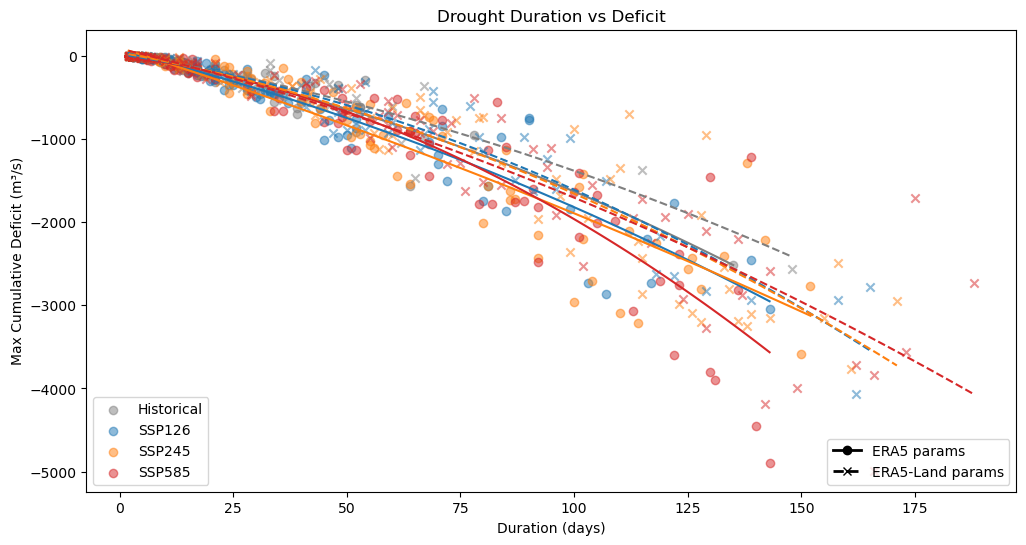

In [15]:
# Run drought analyser (ERA5 parameters)
historical_droughts = drought_analyser(historical_output, '', 66.5)
SSP126_droughts = drought_analyser(SSP126_output, '', 66.5)
SSP245_droughts = drought_analyser(SSP245_output, '', 66.5)
SSP585_droughts = drought_analyser(SSP585_output, '', 66.5)

xh, yh = historical_droughts["Duration (days)"], historical_droughts["Max Cumulative Deficit (m3/s)"]
x1, y1 = SSP126_droughts["Duration (days)"], SSP126_droughts["Max Cumulative Deficit (m3/s)"]
x2, y2 = SSP245_droughts["Duration (days)"], SSP245_droughts["Max Cumulative Deficit (m3/s)"]
x5, y5 = SSP585_droughts["Duration (days)"], SSP585_droughts["Max Cumulative Deficit (m3/s)"]

# Run drought analyser (ERA5-Land parameters)
historical_droughts_land = drought_analyser(historical_output_land, '', 66.5)
SSP126_droughts_land = drought_analyser(SSP126_output_land, '', 66.5)
SSP245_droughts_land = drought_analyser(SSP245_output_land, '', 66.5)
SSP585_droughts_land = drought_analyser(SSP585_output_land, '', 66.5)

xh_land, yh_land = historical_droughts_land["Duration (days)"], historical_droughts_land["Max Cumulative Deficit (m3/s)"]
x1_land, y1_land = SSP126_droughts_land["Duration (days)"], SSP126_droughts_land["Max Cumulative Deficit (m3/s)"]
x2_land, y2_land = SSP245_droughts_land["Duration (days)"], SSP245_droughts_land["Max Cumulative Deficit (m3/s)"]
x5_land, y5_land = SSP585_droughts_land["Duration (days)"], SSP585_droughts_land["Max Cumulative Deficit (m3/s)"]


# Functie voor polyfit en plot
def plot_droughts(x, y, color, label, linestyle='-', marker='o'):
    coeffs = np.polyfit(x, y, 2)
    poly_func = np.poly1d(coeffs)

    x_smooth = np.linspace(x.min(), x.max(), 100)
    y_smooth = poly_func(x_smooth)

    plt.scatter(x, y, color=color, alpha=0.5, label=label, marker=marker)
    plt.plot(x_smooth, y_smooth, color=color, linestyle=linestyle)


plt.figure(figsize=(12, 6))

# ERA5 parameters: filled circles + solid fit
plot_droughts(xh, yh, "#7f7f7f", "Historical")
plot_droughts(x1, y1, "#1f77b4", "SSP126")
plot_droughts(x2, y2, "#ff7f0e", "SSP245")
plot_droughts(x5, y5, "#d62728", "SSP585")

# ERA5-Land parameters: crosses + dashed fit, no label (linestyle legend below)
plot_droughts(xh_land, yh_land, "#7f7f7f", None, '--', 'x')
plot_droughts(x1_land, y1_land, "#1f77b4", None, '--', 'x')
plot_droughts(x2_land, y2_land, "#ff7f0e", None, '--', 'x')
plot_droughts(x5_land, y5_land, "#d62728", None, '--', 'x')

plt.title('Drought Duration vs Deficit')
plt.xlabel('Duration (days)')
plt.ylabel('Max Cumulative Deficit (m³/s)')
leg1 = plt.legend(loc='lower left')  # scenario colors

# Second legend for the parameter sets
style_handles = [plt.Line2D([], [], color='k', lw=2, ls='-', marker='o', label='ERA5 params'),
                 plt.Line2D([], [], color='k', lw=2, ls='--', marker='x', label='ERA5-Land params')]
plt.legend(handles=style_handles, loc='lower right')
plt.gca().add_artist(leg1)  # keep the first legend visible

plt.show()

### 8. Distribution

The distribution for duration and deficit is also plotted to gain a better understanding of the differences between each scenario. For this, Seaborn's kdeplot is used to plot these distributions.

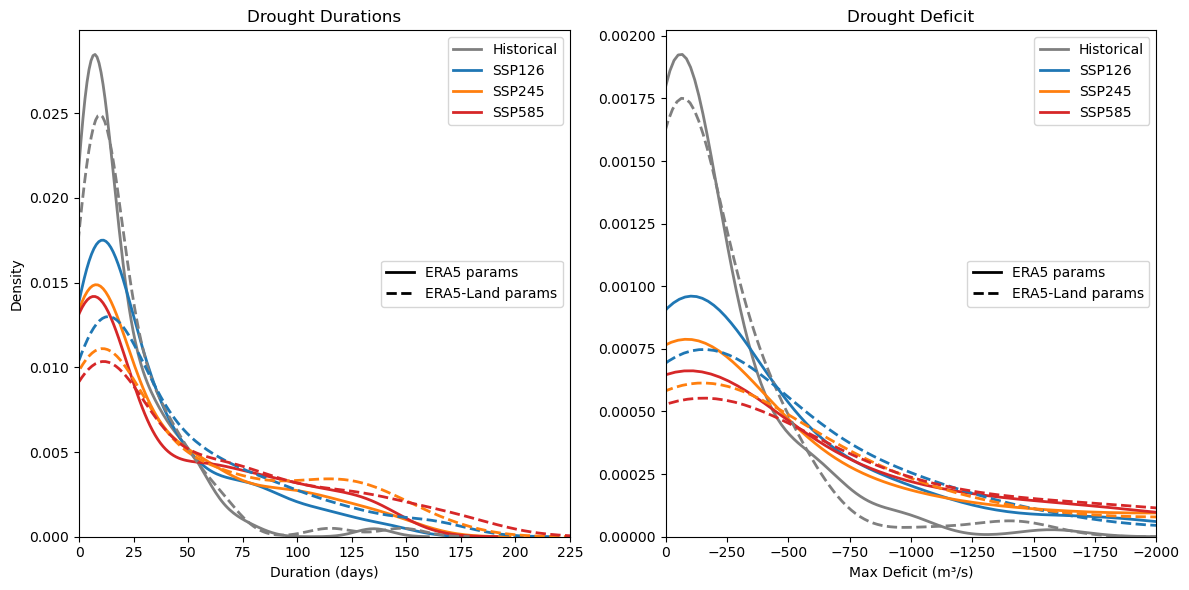

In [16]:
# Plotting: ERA5 (solid) vs ERA5-Land (dashed) parameters
plt.figure(figsize=(12, 6))

# Plot 1: Duration
plt.subplot(1, 2, 1)
sns.kdeplot(xh, label='Historical', color="#7f7f7f", linewidth=2)
sns.kdeplot(x1, label='SSP126', color="#1f77b4", linewidth=2)
sns.kdeplot(x2, label='SSP245', color="#ff7f0e", linewidth=2)
sns.kdeplot(x5, label='SSP585', color="#d62728", linewidth=2)
# ERA5-Land: same colors, dashed, no label (linestyle legend is added below)
sns.kdeplot(xh_land, color="#7f7f7f", linewidth=2, linestyle='--')
sns.kdeplot(x1_land, color="#1f77b4", linewidth=2, linestyle='--')
sns.kdeplot(x2_land, color="#ff7f0e", linewidth=2, linestyle='--')
sns.kdeplot(x5_land, color="#d62728", linewidth=2, linestyle='--')
plt.title('Drought Durations')
plt.xlabel('Duration (days)')
plt.xlim(0, 225)
leg1 = plt.legend(loc='upper right')  # scenario colors
# Second legend for the parameter sets (grey sample lines)
style_handles = [plt.Line2D([], [], color='k', lw=2, ls='-', label='ERA5 params'),
                 plt.Line2D([], [], color='k', lw=2, ls='--', label='ERA5-Land params')]
plt.legend(handles=style_handles, loc='center right')
plt.gca().add_artist(leg1)  # keep the first legend visible

# Plot 2: Deficit
plt.subplot(1, 2, 2)
sns.kdeplot(yh, label='Historical', color="#7f7f7f", linewidth=2)
sns.kdeplot(y1, label='SSP126', color="#1f77b4", linewidth=2)
sns.kdeplot(y2, label='SSP245', color="#ff7f0e", linewidth=2)
sns.kdeplot(y5, label='SSP585', color="#d62728", linewidth=2)
sns.kdeplot(yh_land, color="#7f7f7f", linewidth=2, linestyle='--')
sns.kdeplot(y1_land, color="#1f77b4", linewidth=2, linestyle='--')
sns.kdeplot(y2_land, color="#ff7f0e", linewidth=2, linestyle='--')
sns.kdeplot(y5_land, color="#d62728", linewidth=2, linestyle='--')
plt.title('Drought Deficit')
plt.xlabel('Max Deficit (m³/s)')
plt.ylabel('')
plt.xlim(-2000, 0)
plt.gca().invert_xaxis()
leg2 = plt.legend(loc='upper right')
plt.legend(handles=style_handles, loc='center right')
plt.gca().add_artist(leg2)

plt.tight_layout()
plt.show()

### 9. Cumulative distribution

The fitted line in Chapter 7 and the distribution did not give the best results to visually analyse the scenarios. For this, the cumulative distribution is used as it better displays the differences.

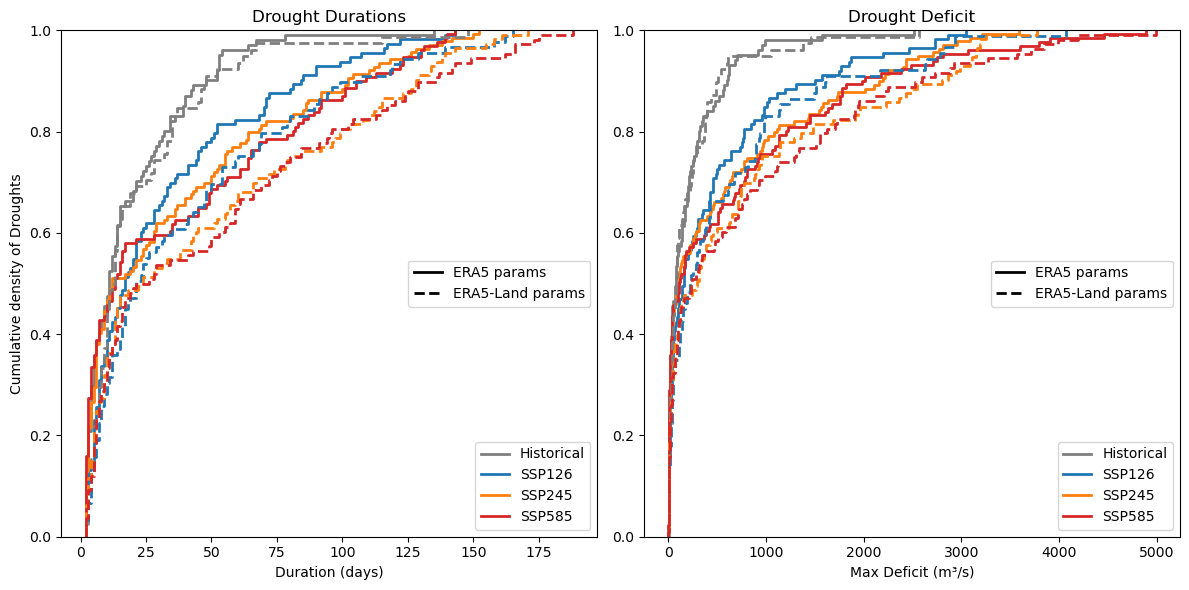

In [17]:
plt.figure(figsize=(12, 6))

# Legend handles for the parameter sets (used in both subplots)
style_handles = [plt.Line2D([], [], color='k', lw=2, ls='-', label='ERA5 params'),
                 plt.Line2D([], [], color='k', lw=2, ls='--', label='ERA5-Land params')]

# Plot 1: Duration
plt.subplot(1, 2, 1)
sns.ecdfplot(xh, label='Historical', color="#7f7f7f", linewidth=2)
sns.ecdfplot(x1, label='SSP126', color="#1f77b4", linewidth=2)
sns.ecdfplot(x2, label='SSP245', color="#ff7f0e", linewidth=2)
sns.ecdfplot(x5, label='SSP585', color="#d62728", linewidth=2)
# ERA5-Land: same colors, dashed, no label
sns.ecdfplot(xh_land, color="#7f7f7f", linewidth=2, linestyle='--')
sns.ecdfplot(x1_land, color="#1f77b4", linewidth=2, linestyle='--')
sns.ecdfplot(x2_land, color="#ff7f0e", linewidth=2, linestyle='--')
sns.ecdfplot(x5_land, color="#d62728", linewidth=2, linestyle='--')
plt.title('Drought Durations')
plt.xlabel('Duration (days)')
plt.ylabel('Cumulative density of Droughts')
leg1 = plt.legend(loc='lower right')  # scenario colors
plt.legend(handles=style_handles, loc='center right')
plt.gca().add_artist(leg1)  # keep the first legend visible

# Plot 2: Deficit
plt.subplot(1, 2, 2)
sns.ecdfplot(yh*-1, label='Historical', color="#7f7f7f", linewidth=2)
sns.ecdfplot(y1*-1, label='SSP126', color="#1f77b4", linewidth=2)
sns.ecdfplot(y2*-1, label='SSP245', color="#ff7f0e", linewidth=2)
sns.ecdfplot(y5*-1, label='SSP585', color="#d62728", linewidth=2)
sns.ecdfplot(yh_land*-1, color="#7f7f7f", linewidth=2, linestyle='--')
sns.ecdfplot(y1_land*-1, color="#1f77b4", linewidth=2, linestyle='--')
sns.ecdfplot(y2_land*-1, color="#ff7f0e", linewidth=2, linestyle='--')
sns.ecdfplot(y5_land*-1, color="#d62728", linewidth=2, linestyle='--')
plt.title('Drought Deficit')
plt.xlabel('Max Deficit (m³/s)')
plt.ylabel('')
#plt.gca().invert_axis()
leg2 = plt.legend(loc='lower right')
plt.legend(handles=style_handles, loc='center right')
plt.gca().add_artist(leg2)

plt.tight_layout()
plt.show()

### 10. Return period

The visual analysis is done in Chapter 9, yet to give a quantitative conclusion on the differences, the return period is used. 
For the return period of droughts the following functions are used:

T_D = N / (n(1 - F_D(d)))

T_S = N / (n(1 - F_S(s)))

- T_D = return period for duration
- T_S = return period for severity
- N = length of the experiment period
- n = amount of occurences
- F_D(d) = cumulative distribution for drought duration (displayed in chapter 9, left plot)
- F_S(s) = cumulative distribution for drought severity (displayed in chapter 9, right plot)

A correction factor CF=2.2 is applied for drought severity as it showed bias during validation on the period 1990-2014. This correction factor was manually defined in chapter 11.

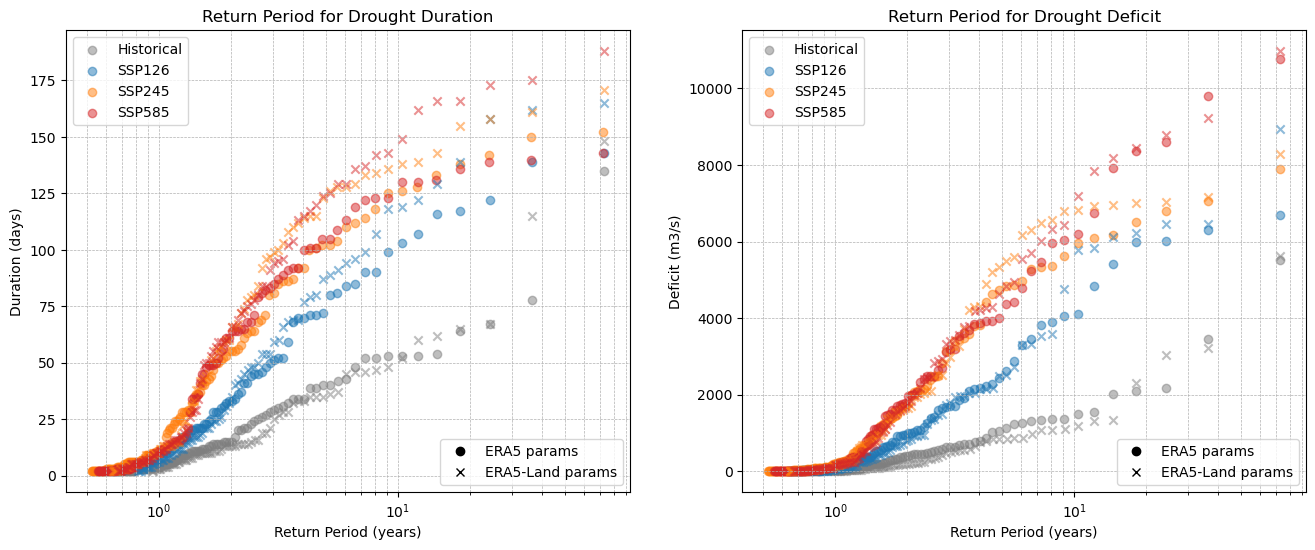

In [18]:
def plot_return_period(data, years, color, label, marker='o'):
    sorted_data = np.sort(data)
    N = years
    n = len(sorted_data)

    # Emperical cumulative distribution
    F = np.arange(1, n + 1) / (n + 1)

    # Return Period
    return_period = N / (n * (1 - F))

    # Plot
    plt.scatter(return_period, sorted_data, color=color, alpha=0.5, label=label, marker=marker)


# Correction factor per parameter set
CF_era5 = 2.2
CF_land = 2.2  # TODO: re-tune in chapter 11 (ERA5-Land cell)

# Legend handles for the parameter sets (used in both subplots)
style_handles = [plt.Line2D([], [], color='k', ls='none', marker='o', label='ERA5 params'),
                 plt.Line2D([], [], color='k', ls='none', marker='x', label='ERA5-Land params')]

# Plot
plt.figure(figsize=(16, 6))

# Duration
plt.subplot(1, 2, 1)
plot_return_period(xh, 72, "#7f7f7f", "Historical")
plot_return_period(x1, 72, "#1f77b4", "SSP126")
plot_return_period(x2, 72, "#ff7f0e", "SSP245")
plot_return_period(x5, 72, "#d62728", "SSP585")
# ERA5-Land: same colors, crosses, no label
plot_return_period(xh_land, 72, "#7f7f7f", None, 'x')
plot_return_period(x1_land, 72, "#1f77b4", None, 'x')
plot_return_period(x2_land, 72, "#ff7f0e", None, 'x')
plot_return_period(x5_land, 72, "#d62728", None, 'x')

plt.xscale('log')
plt.title('Return Period for Drought Duration')
plt.xlabel('Return Period (years)')
plt.ylabel('Duration (days)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
leg1 = plt.legend(loc='upper left')  # scenario colors
plt.legend(handles=style_handles, loc='lower right')
plt.gca().add_artist(leg1)  # keep the first legend visible

# Deficit
plt.subplot(1, 2, 2)
plot_return_period(yh*-CF_era5, 72, "#7f7f7f", "Historical")
plot_return_period(y1*-CF_era5, 72, "#1f77b4", "SSP126")
plot_return_period(y2*-CF_era5, 72, "#ff7f0e", "SSP245")
plot_return_period(y5*-CF_era5, 72, "#d62728", "SSP585")
plot_return_period(yh_land*-CF_land, 72, "#7f7f7f", None, 'x')
plot_return_period(y1_land*-CF_land, 72, "#1f77b4", None, 'x')
plot_return_period(y2_land*-CF_land, 72, "#ff7f0e", None, 'x')
plot_return_period(y5_land*-CF_land, 72, "#d62728", None, 'x')

plt.xscale('log')
plt.title('Return Period for Drought Deficit')
plt.xlabel('Return Period (years)')
plt.ylabel('Deficit (m3/s)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
leg2 = plt.legend(loc='upper left')
plt.legend(handles=style_handles, loc='lower right')
plt.gca().add_artist(leg2)

plt.show()

### 11. Determine correction factor

Based on the validation of CMIP6 historical discharge and observed discharge for the period 1990-2014, drought duration does not require a correction factor (CF). However, drought severity shows signification error. For this, a CF is created. The CF is determined by checking which factor fits best (the CF is adjusted untill the result is satisfactory, no algorithm is used to do this).

ERA5:      mean observed / mean modelled deficit = 0.53 (current CF = 2.2)

ERA5-Land: mean observed / mean modelled deficit = 0.52 (current CF = 2.2)

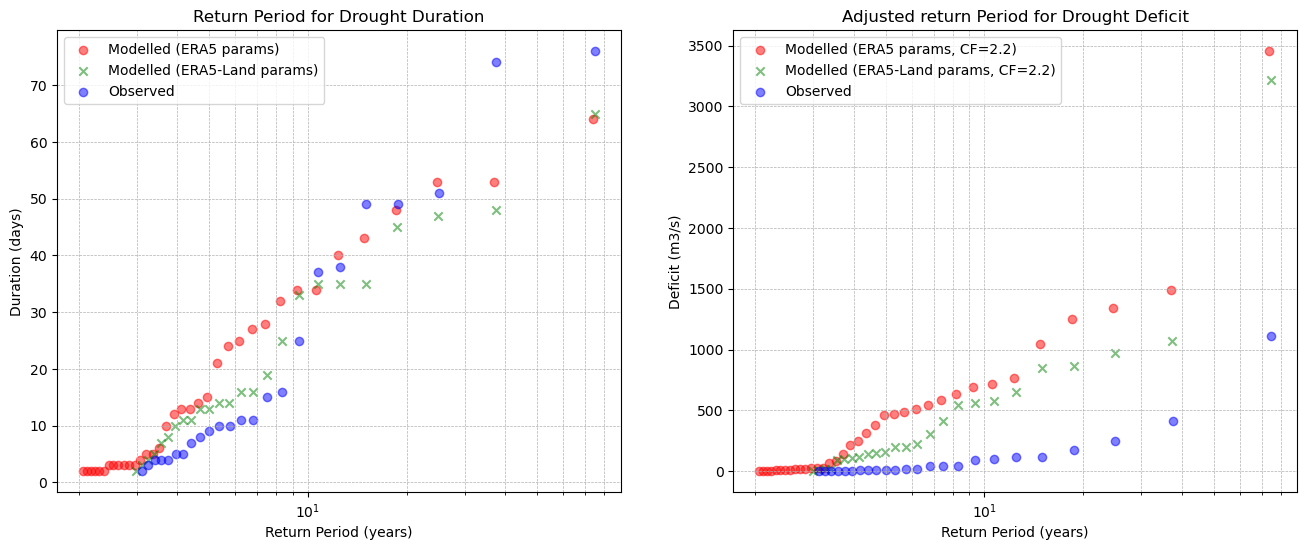

In [19]:
# Loading data for 1990-2014 (note: this overwrites xh / yh from chapter 7)
historical_observations = pd.Series(data=output[0], name="Historical", index=years[0])["1990-01-01":]
historical_observations *= factor

# ERA5-Land parameters, same period
historical_observations_land = pd.Series(data=output_land[0], name="Historical", index=years_land[0])["1990-01-01":]
historical_observations_land *= factor

cmip_output = pd.read_csv("FR003882_streamflow_m3s.csv", index_col='date', parse_dates=True)["FR003882"]
cmip_9014 = cmip_output['1990-01-01':'2014-12-31']

# Use drought analyser
historical_droughts = drought_analyser(historical_observations, '', 66.5)
historical_droughts_land = drought_analyser(historical_observations_land, '', 66.5)
cmip_droughts = drought_analyser(cmip_9014, '', 66.5)

xh, yh = historical_droughts["Duration (days)"], historical_droughts["Max Cumulative Deficit (m3/s)"]
xh_land, yh_land = historical_droughts_land["Duration (days)"], historical_droughts_land["Max Cumulative Deficit (m3/s)"]
xc, yc = cmip_droughts["Duration (days)"], cmip_droughts["Max Cumulative Deficit (m3/s)"]

# Correction factors: adjust until modelled and observed deficits overlap
CF = 2.2
CF_land = 2.2
# Rough starting point for tuning
print(f"ERA5:      mean observed / mean modelled deficit = {yc.mean() / yh.mean():.2f} (current CF = {CF})")
print(f"ERA5-Land: mean observed / mean modelled deficit = {yc.mean() / yh_land.mean():.2f} (current CF = {CF_land})")

# Plot the return periods for observed and cmip historical data
plt.figure(figsize=(16, 6))

# Duration
plt.subplot(1, 2, 1)
plot_return_period(xh, 72, "red", "Modelled (ERA5 params)")
plot_return_period(xh_land, 72, "green", "Modelled (ERA5-Land params)", 'x')
plot_return_period(xc, 72, "blue", "Observed")

plt.xscale('log')
plt.title('Return Period for Drought Duration')
plt.xlabel('Return Period (years)')
plt.ylabel('Duration (days)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()

# Deficit
plt.subplot(1, 2, 2)
plot_return_period(-yh*CF, 72, "red", f"Modelled (ERA5 params, CF={CF})")
plot_return_period(-yh_land*CF_land, 72, "green", f"Modelled (ERA5-Land params, CF={CF_land})", 'x')
plot_return_period(-yc, 72, "blue", "Observed")

plt.xscale('log')
plt.title('Adjusted return Period for Drought Deficit')
plt.xlabel('Return Period (years)')
plt.ylabel('Deficit (m3/s)')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()

plt.show()

### 12. Comparison ERA5 vs ERA5-Land parameters (ADDED)

Both runs use the same CMIP6 forcing; only the HBV parameters differ (calibrated on ERA5 vs ERA5-Land). This chapter compares how that choice affects (a) the simulated flow regime, (b) the historical performance against observations and (c) the projected change in droughts.

Note: CMIP6 historical is not synchronous with the observed weather, so the historical run is compared with observations on distributions (regime, flow duration curve, drought statistics), not day by day.

In [20]:
# ADDED (new cell)
# Collect results in dicts for the comparison: Q[calibration][scenario]
scenarios = ["Historical", "SSP126", "SSP245", "SSP585"]
calibrations = ["ERA5", "ERA5-Land"]
colors = {"Historical": "#7f7f7f", "SSP126": "#1f77b4", "SSP245": "#ff7f0e", "SSP585": "#d62728"}
line = {"ERA5": "-", "ERA5-Land": "--"}
threshold = 66.5
n_years = 72  # same as chapter 10
CFs = {"ERA5": CF, "ERA5-Land": CF_land}

Q = {
    "ERA5": {"Historical": historical_output, "SSP126": SSP126_output,
             "SSP245": SSP245_output, "SSP585": SSP585_output},
    "ERA5-Land": {"Historical": historical_output_land, "SSP126": SSP126_output_land,
                  "SSP245": SSP245_output_land, "SSP585": SSP585_output_land},
}

# Recompute droughts (chapter 11 overwrites historical_droughts / xh / yh with 1990-2014)
droughts = {cal: {sc: drought_analyser(Q[cal][sc], '', threshold) for sc in scenarios} for cal in calibrations}
dur = {cal: {sc: d["Duration (days)"] for sc, d in droughts[cal].items()} for cal in calibrations}
dfc = {cal: {sc: d["Max Cumulative Deficit (m3/s)"] for sc, d in droughts[cal].items()} for cal in calibrations}

#### 12.1 Flow regime and flow duration curve (ADDED)

Top: mean discharge per calendar month. Bottom: flow duration curve. Solid = ERA5 parameters, dashed = ERA5-Land parameters, black = observed (1942-2014).

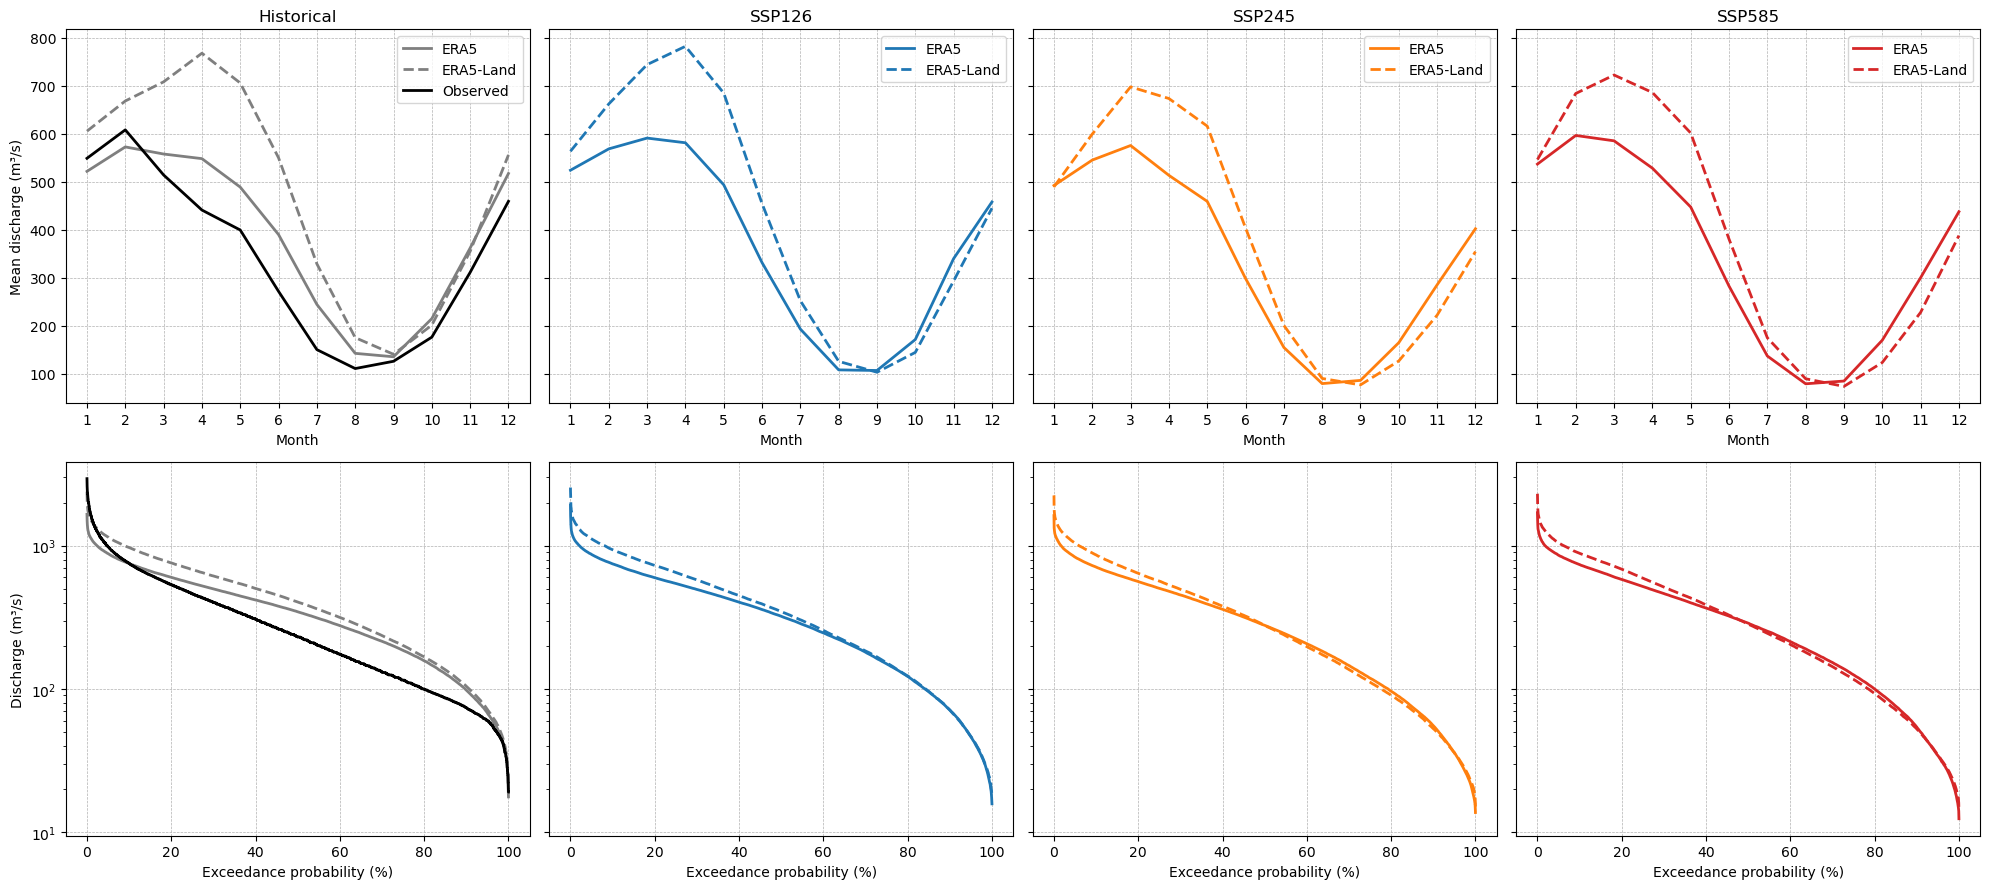

In [21]:
# ADDED (new cell)
def fdc(s):
    # exceedance probability [%], sorted discharge
    q = np.sort(s.dropna().values)[::-1]
    return 100 * np.arange(1, len(q) + 1) / (len(q) + 1), q

fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey='row')

for i, sc in enumerate(scenarios):
    for cal in calibrations:
        s = Q[cal][sc]
        axes[0, i].plot(range(1, 13), s.groupby(s.index.month).mean(), line[cal], color=colors[sc], lw=2, label=cal)
        axes[1, i].plot(*fdc(s), line[cal], color=colors[sc], lw=2, label=cal)

    if sc == "Historical":
        axes[0, i].plot(range(1, 13), q_data_4214.groupby(q_data_4214.index.month).mean(), color="k", lw=2, label="Observed")
        axes[1, i].plot(*fdc(q_data_4214), color="k", lw=2, label="Observed")

    axes[0, i].set(title=sc, xlabel='Month', xticks=range(1, 13))
    axes[1, i].set(xlabel='Exceedance probability (%)', yscale='log')
    axes[0, i].legend()

axes[0, 0].set_ylabel('Mean discharge (m³/s)')
axes[1, 0].set_ylabel('Discharge (m³/s)')
for ax in axes.flat:
    ax.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

#### 12.2 Historical performance against observations (1942-2014) (ADDED)

Distribution-based statistics of the CMIP6 historical run for both parameter sets versus observed discharge. Q95 = low flow exceeded 95% of the time. Deficits are CF-corrected for the model runs.

In [22]:
# ADDED (new cell)
obs_droughts_4214 = drought_analyser(q_data_4214, '', threshold)

def summary_stats(s, d, cf=1.0, years=None):
    # discharge + drought summary for one series
    return {
        "Mean Q (m³/s)": s.mean(),
        "Q5 high flow (m³/s)": s.quantile(0.95),
        "Q95 low flow (m³/s)": s.quantile(0.05),
        "Droughts / year": len(d) / years,
        "Mean duration (days)": d["Duration (days)"].mean(),
        "Max duration (days)": d["Duration (days)"].max(),
        "Mean deficit (m³/s)": -d["Max Cumulative Deficit (m3/s)"].mean() * cf,
        "Max deficit (m³/s)": -d["Max Cumulative Deficit (m3/s)"].min() * cf,
    }

hist_table = pd.DataFrame({
    "Observed": summary_stats(q_data_4214, obs_droughts_4214, years=n_years),
    **{cal: summary_stats(Q[cal]["Historical"], droughts[cal]["Historical"], CFs[cal], n_years)
       for cal in calibrations},
}).T

# Distance between simulated and observed daily discharge distributions (lower = better)
hist_table["Wasserstein distance Q (m³/s)"] = [0.0] + [
    wasserstein_distance(Q[cal]["Historical"].values, q_data_4214.dropna().values) for cal in calibrations
]

display(hist_table.round(2))

# Relative bias vs observed (%)
display((100 * (hist_table.loc[calibrations] / hist_table.loc["Observed"] - 1))
        .drop(columns="Wasserstein distance Q (m³/s)").round(1).add_suffix(" bias (%)"))

,Mean Q (m³/s),Q5 high flow (m³/s),Q95 low flow (m³/s),Droughts / year,Mean duration (days),Max duration (days),Mean deficit (m³/s),Max deficit (m³/s),Wasserstein distance Q (m³/s)
Observed,342.83,984.60,60.00,0.88,41.27,177.0,416.28,4654.00,0.00
ERA5,390.62,880.76,67.65,1.40,18.56,135.0,462.97,5526.54,85.21
ERA5-Land,479.38,1148.69,71.76,1.08,21.44,148.0,482.19,5633.50,142.76


,Mean Q (m³/s) bias (%),Q5 high flow (m³/s) bias (%),Q95 low flow (m³/s) bias (%),Droughts / year bias (%),Mean duration (days) bias (%),Max duration (days) bias (%),Mean deficit (m³/s) bias (%),Max deficit (m³/s) bias (%)
ERA5,13.9,-10.5,12.8,60.3,-55.0,-23.7,11.2,18.7
ERA5-Land,39.8,16.7,19.6,23.8,-48.1,-16.4,15.8,21.0


#### 12.3 Drought statistics per scenario (ADDED)

Absolute statistics per parameter set and scenario, followed by the climate change signal (% change relative to the historical run with the same parameters). The last table shows how much the change signal differs between the two parameter sets (ERA5-Land minus ERA5, in percentage points).

In [23]:
# ADDED (new cell)
stats = pd.DataFrame({
    (cal, sc): summary_stats(Q[cal][sc], droughts[cal][sc], CFs[cal], n_years)
    for cal in calibrations for sc in scenarios
}).T
stats.index.names = ["Parameters", "Scenario"]
display(stats.round(2))

# Change relative to historical run of the same parameter set (%)
change = stats.groupby(level="Parameters", group_keys=False).apply(
    lambda g: 100 * (g / g.xs("Historical", level="Scenario").iloc[0] - 1)
).drop(index="Historical", level="Scenario")
display(change.round(1))

# Difference in change signal: ERA5-Land - ERA5 (percentage points)
display((change.xs("ERA5-Land") - change.xs("ERA5")).round(1))

Mean Q (m³/s)  Q5 high flow (m³/s)  \
Parameters Scenario                                         
ERA5       Historical         390.62               880.76   
           SSP126             371.49               868.81   
           SSP245             337.34               832.57   
           SSP585             347.84               858.08   
ERA5-Land  Historical         479.38              1148.69   
           SSP126             436.91              1116.30   
           SSP245             378.30              1042.08   
           SSP585             390.19              1048.77   

                       Q95 low flow (m³/s)  Droughts / year  \
Parameters Scenario                                           
ERA5       Historical                67.65             1.40   
           SSP126                    46.24             1.57   
           SSP245                    35.88             1.93   
           SSP585                    34.07             1.82   
ERA5-Land  Historical                71.76             1.08   
           SSP126                    46.32             1.24   
           SSP245                    35.68             1.57   
           SSP585                    34.63             1.50   

                       Mean duration (days)  Max duration (days)  \
Parameters Scenario                                                
ERA5       Historical                 18.56                135.0   
           SSP126                     30.87                143.0   
           SSP245                     35.24                152.0   
           SSP585                     37.17                143.0   
ERA5-Land  Historical                 21.44                148.0   
           SSP126                     40.58                165.0   
           SSP245                     47.59                171.0   
           SSP585                     50.19                188.0   

                       Mean deficit (m³/s)  Max deficit (m³/s)  
Parameters Scenario                                             
ERA5       Historical               462.97             5526.54  
           SSP126                  1026.56             6698.36  
           SSP245                  1298.76             7891.09  
           SSP585                  1459.15            10766.46  
ERA5-Land  Historical               482.19             5633.50  
           SSP126                  1299.15             8951.01  
           SSP245                  1677.10             8292.56  
           SSP585                  1809.73            10976.78

Mean Q (m³/s)  Q5 high flow (m³/s)  Q95 low flow (m³/s)  \
Parameters Scenario                                                            
ERA5       SSP126             -4.9                 -1.4                -31.6   
           SSP245            -13.6                 -5.5                -47.0   
           SSP585            -11.0                 -2.6                -49.6   
ERA5-Land  SSP126             -8.9                 -2.8                -35.5   
           SSP245            -21.1                 -9.3                -50.3   
           SSP585            -18.6                 -8.7                -51.7   

                     Droughts / year  Mean duration (days)  \
Parameters Scenario                                          
ERA5       SSP126               11.9                  66.3   
           SSP245               37.6                  89.8   
           SSP585               29.7                 100.2   
ERA5-Land  SSP126               14.1                  89.3   
           SSP245               44.9                 122.0   
           SSP585               38.5                 134.1   

                     Max duration (days)  Mean deficit (m³/s)  \
Parameters Scenario                                             
ERA5       SSP126                    5.9                121.7   
           SSP245                   12.6                180.5   
           SSP585                    5.9                215.2   
ERA5-Land  SSP126                   11.5                169.4   
           SSP245                   15.5                247.8   
           SSP585                   27.0                275.3   

                     Max deficit (m³/s)  
Parameters Scenario                      
ERA5       SSP126                  21.2  
           SSP245                  42.8  
           SSP585                  94.8  
ERA5-Land  SSP126                  58.9  
           SSP245                  47.2  
           SSP585                  94.8

,Mean Q (m³/s),Q5 high flow (m³/s),Q95 low flow (m³/s),Droughts / year,Mean duration (days),Max duration (days),Mean deficit (m³/s),Max deficit (m³/s)
Scenario,,,,,,,,
SSP126,-4.0,-1.5,-3.8,2.2,23.1,5.6,47.7,37.7
SSP245,-7.4,-3.8,-3.3,7.2,32.2,2.9,67.3,4.4
SSP585,-7.7,-6.1,-2.1,8.8,33.9,21.1,60.1,0.0


#### 12.4 Cumulative distributions (ADDED)

Solid = ERA5 parameters, dashed = ERA5-Land parameters, black = observed (1942-2014).

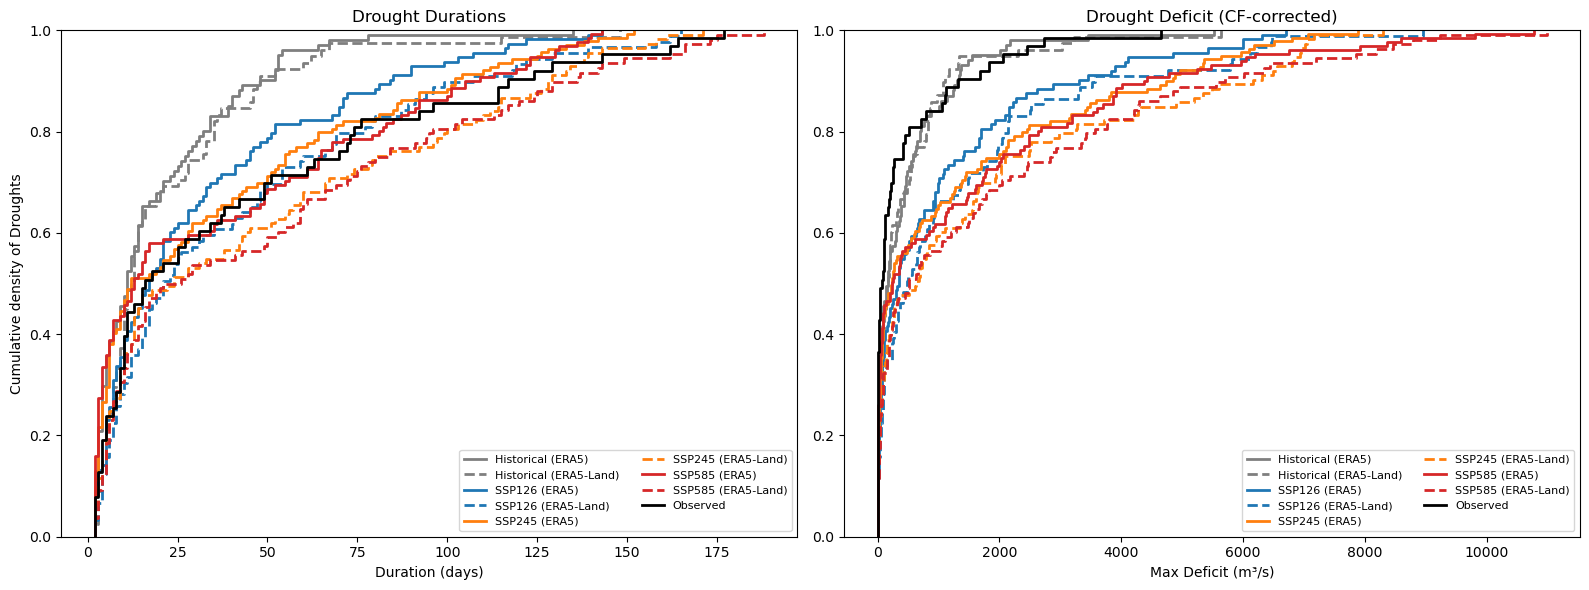

In [24]:
# ADDED (new cell)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for sc in scenarios:
    for cal in calibrations:
        sns.ecdfplot(dur[cal][sc], ax=axes[0], color=colors[sc], ls=line[cal], lw=2, label=f"{sc} ({cal})")
        sns.ecdfplot(-dfc[cal][sc] * CFs[cal], ax=axes[1], color=colors[sc], ls=line[cal], lw=2, label=f"{sc} ({cal})")

sns.ecdfplot(obs_droughts_4214["Duration (days)"], ax=axes[0], color="k", lw=2, label="Observed")
sns.ecdfplot(-obs_droughts_4214["Max Cumulative Deficit (m3/s)"], ax=axes[1], color="k", lw=2, label="Observed")

axes[0].set(title='Drought Durations', xlabel='Duration (days)', ylabel='Cumulative density of Droughts')
axes[1].set(title='Drought Deficit (CF-corrected)', xlabel='Max Deficit (m³/s)', ylabel='')
axes[0].legend(loc='lower right', ncol=2, fontsize=8)
axes[1].legend(loc='lower right', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

#### 12.5 Return levels (ADDED)

Duration and deficit for fixed return periods, interpolated from the empirical return period curves of chapter 10 (NaN if the return period is outside the sample). The bar charts show the change of the 10-year return level relative to the historical run, per parameter set.

Duration (days)

T (years)                2      5      10     25     50
Parameters Scenario                                    
ERA5       Historical  15.0   40.0   53.0   67.7   99.4
           SSP126      33.0   75.6  101.8  123.1  140.5
           SSP245      55.0  102.0  125.7  142.5  150.8
           SSP585      63.2  105.0  128.0  139.1  141.1
ERA5-Land  Historical  13.0   35.4   50.7   69.7  127.3
           SSP126      33.8   87.8  118.7  158.2  163.1
           SSP245      64.1  124.4  137.4  158.2  164.8
           SSP585      64.3  124.4  147.2  173.1  179.9

Deficit (m³/s, CF-corrected)

T (years)                  2       5       10      25       50
Parameters Scenario                                           
ERA5       Historical   383.2  1085.1  1454.3  2246.3   4232.4
           SSP126       974.0  2518.6  4091.7  6022.0   6454.1
           SSP245      1757.0  4784.4  5871.8  6820.2   7373.6
           SSP585      1907.8  4177.9  6155.5  8672.3  10167.7
ERA5-Land  Historical   196.1   838.3  1158.0  3033.9   4117.1
           SSP126       800.8  2504.2  5471.2  6463.2   7394.4
           SSP245      1641.0  5410.0  6822.8  7046.9   7585.2
           SSP585      1755.6  4730.9  6973.6  8806.6   9883.3

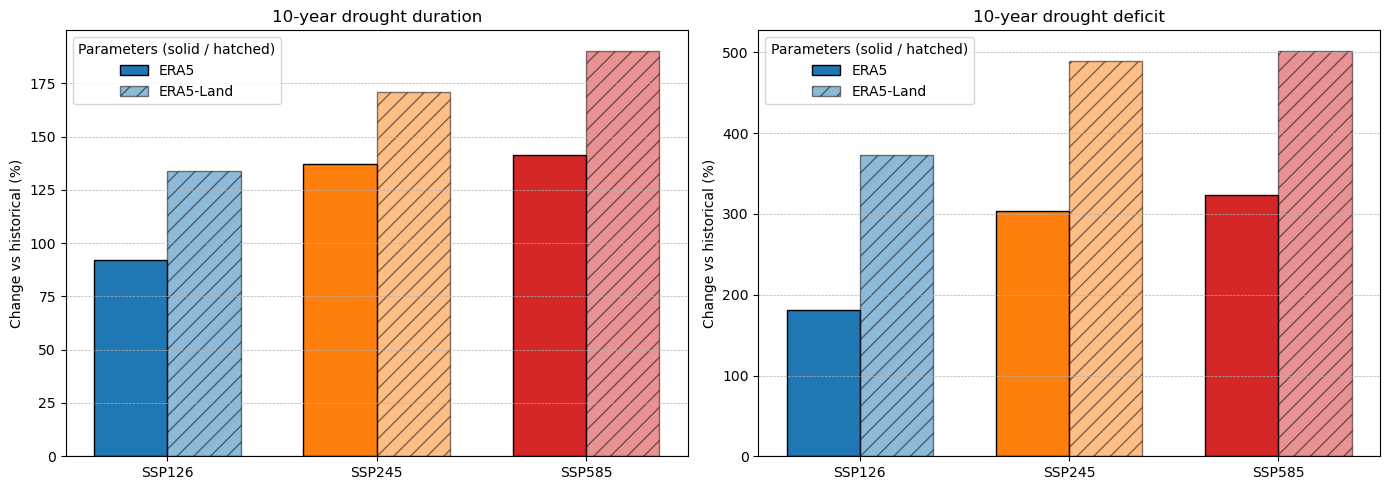

In [25]:
# ADDED (new cell)
T = [2, 5, 10, 25, 50]

def return_levels(data, years, T):
    # interpolate empirical return period curve at return periods T
    s = np.sort(np.asarray(data))
    n = len(s)
    rp = years / (n * (1 - np.arange(1, n + 1) / (n + 1)))
    return np.interp(T, rp, s, left=np.nan, right=np.nan)

rl_dur = pd.DataFrame({(cal, sc): return_levels(dur[cal][sc], n_years, T)
                       for cal in calibrations for sc in scenarios}, index=T).T
rl_def = pd.DataFrame({(cal, sc): return_levels(-dfc[cal][sc] * CFs[cal], n_years, T)
                       for cal in calibrations for sc in scenarios}, index=T).T
for rl in (rl_dur, rl_def):
    rl.index.names = ["Parameters", "Scenario"]
    rl.columns.name = "T (years)"

print("Duration (days)")
display(rl_dur.round(1))
print("Deficit (m³/s, CF-corrected)")
display(rl_def.round(1))

# Change of 10-year return level vs historical (%)
T_sel = 10
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
width = 0.35
ssps = scenarios[1:]
xpos = np.arange(len(ssps))

for ax, rl, title in zip(axes, [rl_dur, rl_def], ["Duration", "Deficit"]):
    for k, cal in enumerate(calibrations):
        hist = rl.loc[(cal, "Historical"), T_sel]
        delta = [100 * (rl.loc[(cal, sc), T_sel] / hist - 1) for sc in ssps]
        ax.bar(xpos + (k - 0.5) * width, delta, width, label=cal,
               color=[colors[sc] for sc in ssps], alpha=1.0 if k == 0 else 0.5,
               hatch=None if k == 0 else "//", edgecolor="k")
    ax.axhline(0, color="k", lw=0.8)
    ax.set(xticks=xpos, xticklabels=ssps, ylabel='Change vs historical (%)',
           title=f'{T_sel}-year drought {title.lower()}')
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
    ax.legend(title="Parameters (solid / hatched)")

plt.tight_layout()
plt.show()

#### 12.6 Reanalysis-forced runs (ERA5 / ERA5-Land) (ADDED)

HBV is also forced with the ERA5 and ERA5-Land reanalysis (1990-2019). Unlike CMIP6, these runs follow the observed weather, so they can be compared with observations day by day. This separates two sources of difference:

- **Model + parameters**: reanalysis run vs observations (KGE, NSE, drought statistics).
- **Climate model forcing**: CMIP6 historical run vs reanalysis run with the same parameters. If the deficit bias only shows up in the CMIP6 run, the CF corrects for CMIP6 forcing rather than for HBV.

All four forcing × parameter combinations are run, so the effect of the forcing and of the parameters can be seen separately. Label = forcing / parameters.

In [26]:
# ADDED (new cell)
label = {key: f"{key[0]} forcing / {key[1]} params" for key in Q_rea}
matched = [("ERA5", "ERA5"), ("ERA5-Land", "ERA5-Land")]
colors_rea = {("ERA5", "ERA5"): "#1f77b4", ("ERA5", "ERA5-Land"): "#9ecae1",
              ("ERA5-Land", "ERA5-Land"): "#2ca02c", ("ERA5-Land", "ERA5"): "#98df8a"}

def aligned(sim, obs):
    # daily sim/obs pairs on common, non-NaN dates
    df = pd.concat([sim.rename("sim"), obs.rename("obs")], axis=1, join="inner").dropna()
    if df.empty:
        raise ValueError(f"No overlapping dates: sim {sim.index[0]} - {sim.index[-1]} ({sim.index.dtype}), "
                         f"obs {obs.index[0]} - {obs.index[-1]} ({obs.index.dtype})")
    return df["sim"].values, df["obs"].values

def nse(sim, obs):
    return 1 - np.sum((sim - obs) ** 2) / np.sum((obs - obs.mean()) ** 2)

def kge(sim, obs):
    r = np.corrcoef(sim, obs)[0, 1]
    alpha = sim.std() / obs.std()   # variability ratio
    beta = sim.mean() / obs.mean()  # bias ratio
    return 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2), r, alpha, beta

# Daily performance vs observations over the full reanalysis period
rows = {}
for key, s in Q_rea.items():
    sim, obs = aligned(s, q_data)
    k, r, a, b = kge(sim, obs)
    rows[label[key]] = {
        "KGE": k, "r": r, "alpha": a, "beta": b,
        "NSE": nse(sim, obs),
        "NSE log Q (low flows)": nse(np.log(sim + 1e-3), np.log(obs + 1e-3)),
        "RMSE (m³/s)": np.sqrt(mean_squared_error(obs, sim)),
    }
    period = f"{s.index[0].date()} - {s.index[-1].date()}"

print(f"Daily performance vs observed ({period})")
display(pd.DataFrame(rows).T.round(3))

Daily performance vs observed (1991-01-01 - 2019-12-31)

,KGE,r,alpha,beta,NSE,NSE log Q (low flows),RMSE (m³/s)
ERA5 forcing / ERA5 params,0.595,0.804,0.647,1.036,0.620,0.525,180.117
ERA5 forcing / ERA5-Land params,0.722,0.853,0.877,1.201,0.678,0.534,165.753
ERA5-Land forcing / ERA5 params,0.599,0.802,0.656,1.054,0.618,0.516,180.572
ERA5-Land forcing / ERA5-Land params,0.681,0.842,0.885,1.252,0.631,0.475,177.597


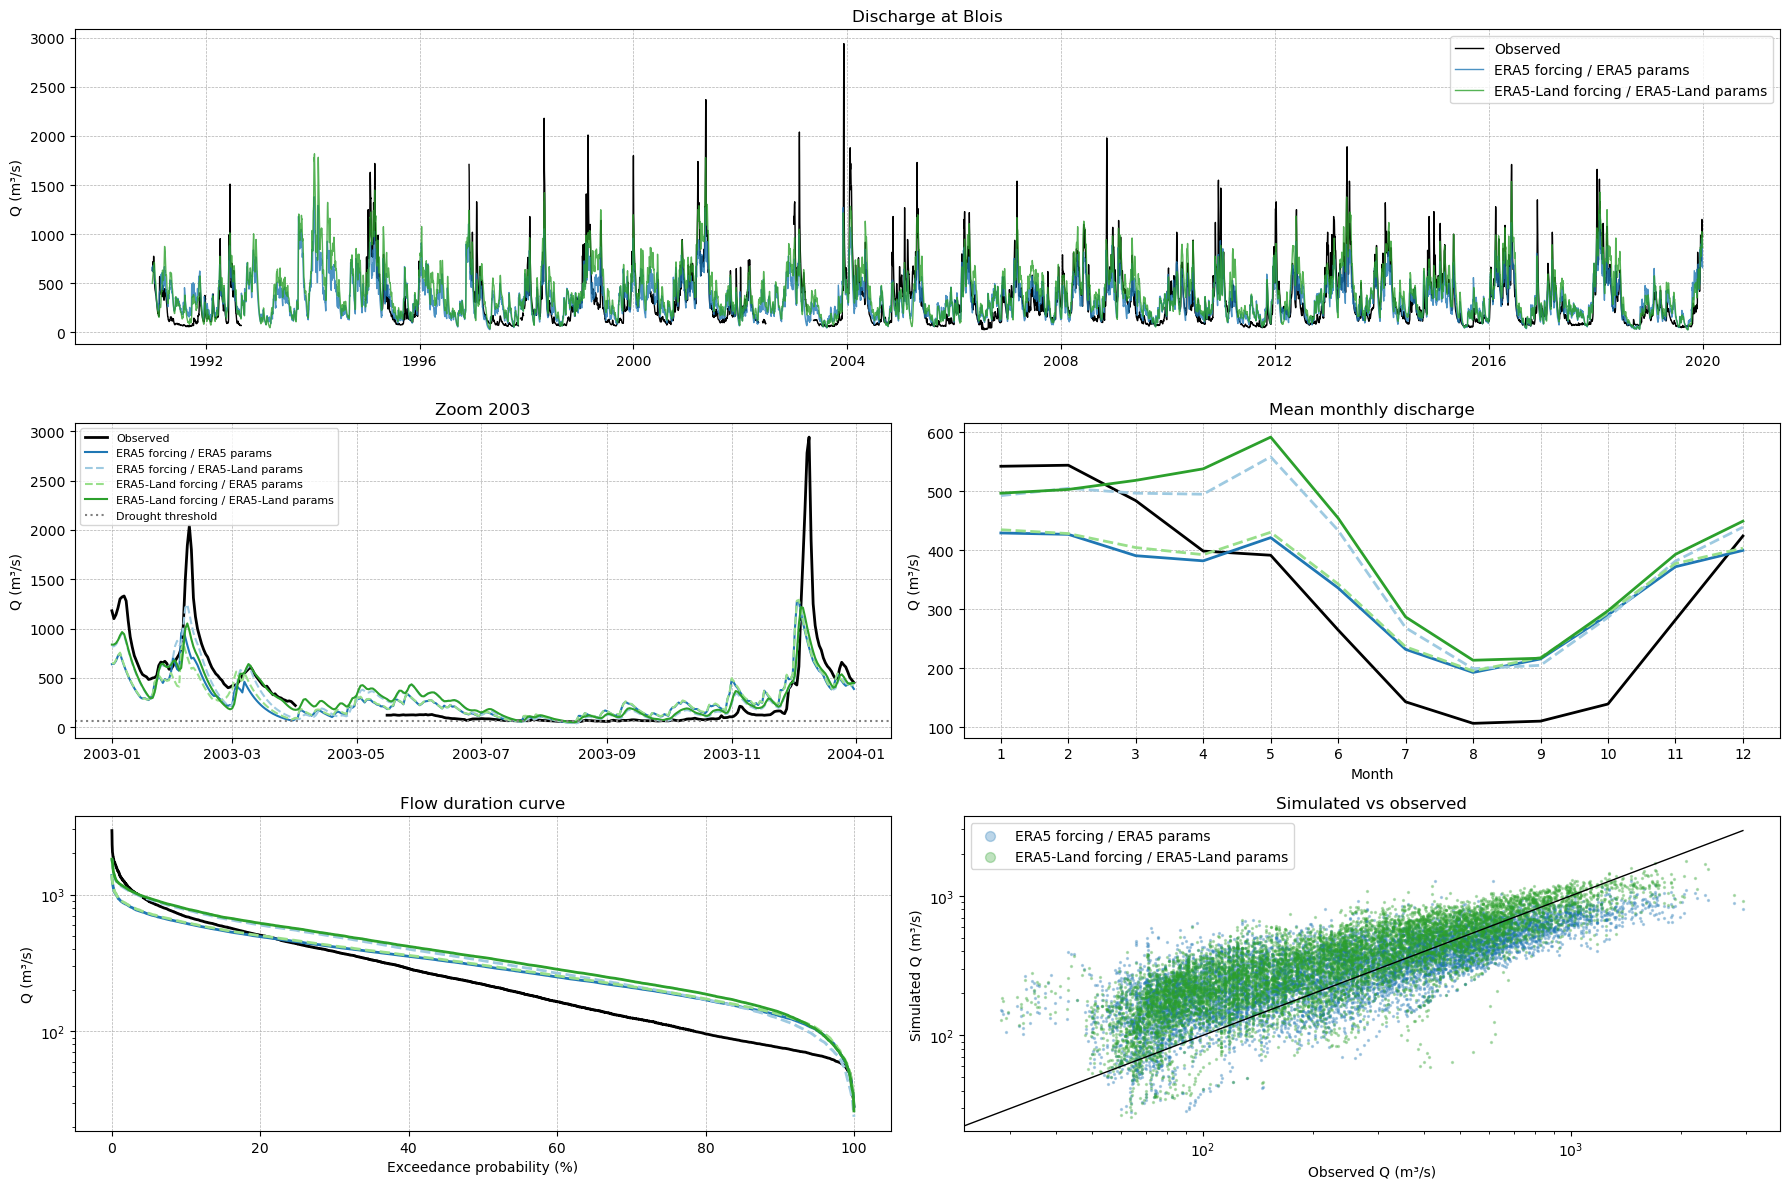

In [27]:
# ADDED (new cell)
# Hydrographs: full period + zoom on a dry year, and flow duration curves
zoom_year = "2003"  # European drought year; change to inspect other years
obs_rea = q_data[Q_rea[matched[0]].index[0]:Q_rea[matched[0]].index[-1]]

fig = plt.figure(figsize=(18, 12))
ax1 = fig.add_subplot(3, 1, 1)
ax2 = fig.add_subplot(3, 2, 3)
ax3 = fig.add_subplot(3, 2, 4)
ax4 = fig.add_subplot(3, 2, 5)
ax5 = fig.add_subplot(3, 2, 6)

ax1.plot(obs_rea, color="k", lw=1, label="Observed")
for key in matched:
    ax1.plot(Q_rea[key], color=colors_rea[key], lw=1, alpha=0.8, label=label[key])
ax1.set(title="Discharge at Blois", ylabel="Q (m³/s)")
ax1.legend()

ax2.plot(obs_rea[zoom_year], color="k", lw=2, label="Observed")
for key in Q_rea:
    ax2.plot(Q_rea[key][zoom_year], color=colors_rea[key], lw=1.5, ls="-" if key in matched else "--", label=label[key])
ax2.axhline(66.5, color="grey", ls=":", label="Drought threshold")
ax2.set(title=f"Zoom {zoom_year}", ylabel="Q (m³/s)")
ax2.legend(fontsize=8)

# Mean monthly regime
ax3.plot(range(1, 13), obs_rea.groupby(obs_rea.index.month).mean(), color="k", lw=2, label="Observed")
for key in Q_rea:
    s = Q_rea[key]
    ax3.plot(range(1, 13), s.groupby(s.index.month).mean(), color=colors_rea[key], lw=2, ls="-" if key in matched else "--", label=label[key])
ax3.set(title="Mean monthly discharge", xlabel="Month", ylabel="Q (m³/s)", xticks=range(1, 13))

# Flow duration curve
ax4.plot(*fdc(obs_rea), color="k", lw=2, label="Observed")
for key in Q_rea:
    ax4.plot(*fdc(Q_rea[key]), color=colors_rea[key], lw=2, ls="-" if key in matched else "--", label=label[key])
ax4.set(title="Flow duration curve", xlabel="Exceedance probability (%)", ylabel="Q (m³/s)", yscale="log")

# Scatter sim vs obs (matched runs)
for key in matched:
    sim, obs = aligned(Q_rea[key], q_data)
    ax5.scatter(obs, sim, s=2, alpha=0.3, color=colors_rea[key], label=label[key])
lim = [0, max(obs_rea.max(), max(Q_rea[k].max() for k in matched))]
ax5.plot(lim, lim, color="k", lw=1)
ax5.set(title="Simulated vs observed", xlabel="Observed Q (m³/s)", ylabel="Simulated Q (m³/s)", xscale="log", yscale="log")
ax5.legend(markerscale=5)

for ax in (ax1, ax2, ax3, ax4):
    ax.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

Droughts over the common period 1991-2014 (reanalysis starts 1991 after spin-up, CMIP6 historical ends 2014). Deficits are **not** CF-corrected here, so the table shows directly where the bias comes from; the last column shows the CMIP6 deficit after CF for reference. (ADDED)

In [28]:
# ADDED (new cell)
p0, p1 = "1991-01-01", "2014-12-31"
years_common = (pd.Timestamp(p1) - pd.Timestamp(p0)).days / 365.25

series_common = {"Observed": q_data[p0:p1]}
for key in Q_rea:
    series_common[f"Reanalysis: {label[key]}"] = Q_rea[key][p0:p1]
for cal in calibrations:
    series_common[f"CMIP6 hist / {cal} params"] = Q[cal]["Historical"][p0:p1]

droughts_common = {name: drought_analyser(s, '', threshold) for name, s in series_common.items()}

common_table = pd.DataFrame({name: summary_stats(s, droughts_common[name], years=years_common)
                             for name, s in series_common.items()}).T
common_table["Mean deficit ×CF (m³/s)"] = [
    common_table.loc[name, "Mean deficit (m³/s)"] * CFs[name.split("/ ")[1].replace(" params", "")]
    if name.startswith("CMIP6") else np.nan
    for name in common_table.index
]
display(common_table.round(2))

# Bias vs observed (%)
display((100 * (common_table.drop(index="Observed").drop(columns="Mean deficit ×CF (m³/s)")
                / common_table.loc["Observed"].drop("Mean deficit ×CF (m³/s)") - 1)).round(1).add_suffix(" bias (%)"))

,Mean Q (m³/s),Q5 high flow (m³/s),Q95 low flow (m³/s),Droughts / year,Mean duration (days),Max duration (days),Mean deficit (m³/s),Max deficit (m³/s),Mean deficit ×CF (m³/s)
Observed,328.90,906.45,68.66,0.88,20.86,76.0,115.75,1108.40,NaN
Reanalysis: ERA5 forcing / ERA5 params,346.32,719.10,114.50,0.46,7.27,25.0,67.03,451.03,NaN
Reanalysis: ERA5 forcing / ERA5-Land params,406.20,930.76,103.47,0.79,7.84,22.0,53.52,319.95,NaN
Reanalysis: ERA5-Land forcing / ERA5 params,352.21,729.49,117.12,0.46,6.36,24.0,59.77,435.07,NaN
Reanalysis: ERA5-Land forcing / ERA5-Land params,422.79,947.90,115.59,0.50,7.33,17.0,46.97,240.36,NaN
CMIP6 hist / ERA5 params,392.82,904.97,67.75,1.46,17.69,64.0,195.02,1570.45,429.05
CMIP6 hist / ERA5-Land params,479.00,1168.06,74.77,1.00,20.79,65.0,198.74,1464.32,437.22


,Mean Q (m³/s) bias (%),Q5 high flow (m³/s) bias (%),Q95 low flow (m³/s) bias (%),Droughts / year bias (%),Mean duration (days) bias (%),Max duration (days) bias (%),Mean deficit (m³/s) bias (%),Max deficit (m³/s) bias (%)
Reanalysis: ERA5 forcing / ERA5 params,5.3,-20.7,66.8,-47.6,-65.1,-67.1,-42.1,-59.3
Reanalysis: ERA5 forcing / ERA5-Land params,23.5,2.7,50.7,-9.5,-62.4,-71.1,-53.8,-71.1
Reanalysis: ERA5-Land forcing / ERA5 params,7.1,-19.5,70.6,-47.6,-69.5,-68.4,-48.4,-60.7
Reanalysis: ERA5-Land forcing / ERA5-Land params,28.5,4.6,68.4,-42.9,-64.8,-77.6,-59.4,-78.3
CMIP6 hist / ERA5 params,19.4,-0.2,-1.3,66.7,-15.2,-15.8,68.5,41.7
CMIP6 hist / ERA5-Land params,45.6,28.9,8.9,14.3,-0.3,-14.5,71.7,32.1


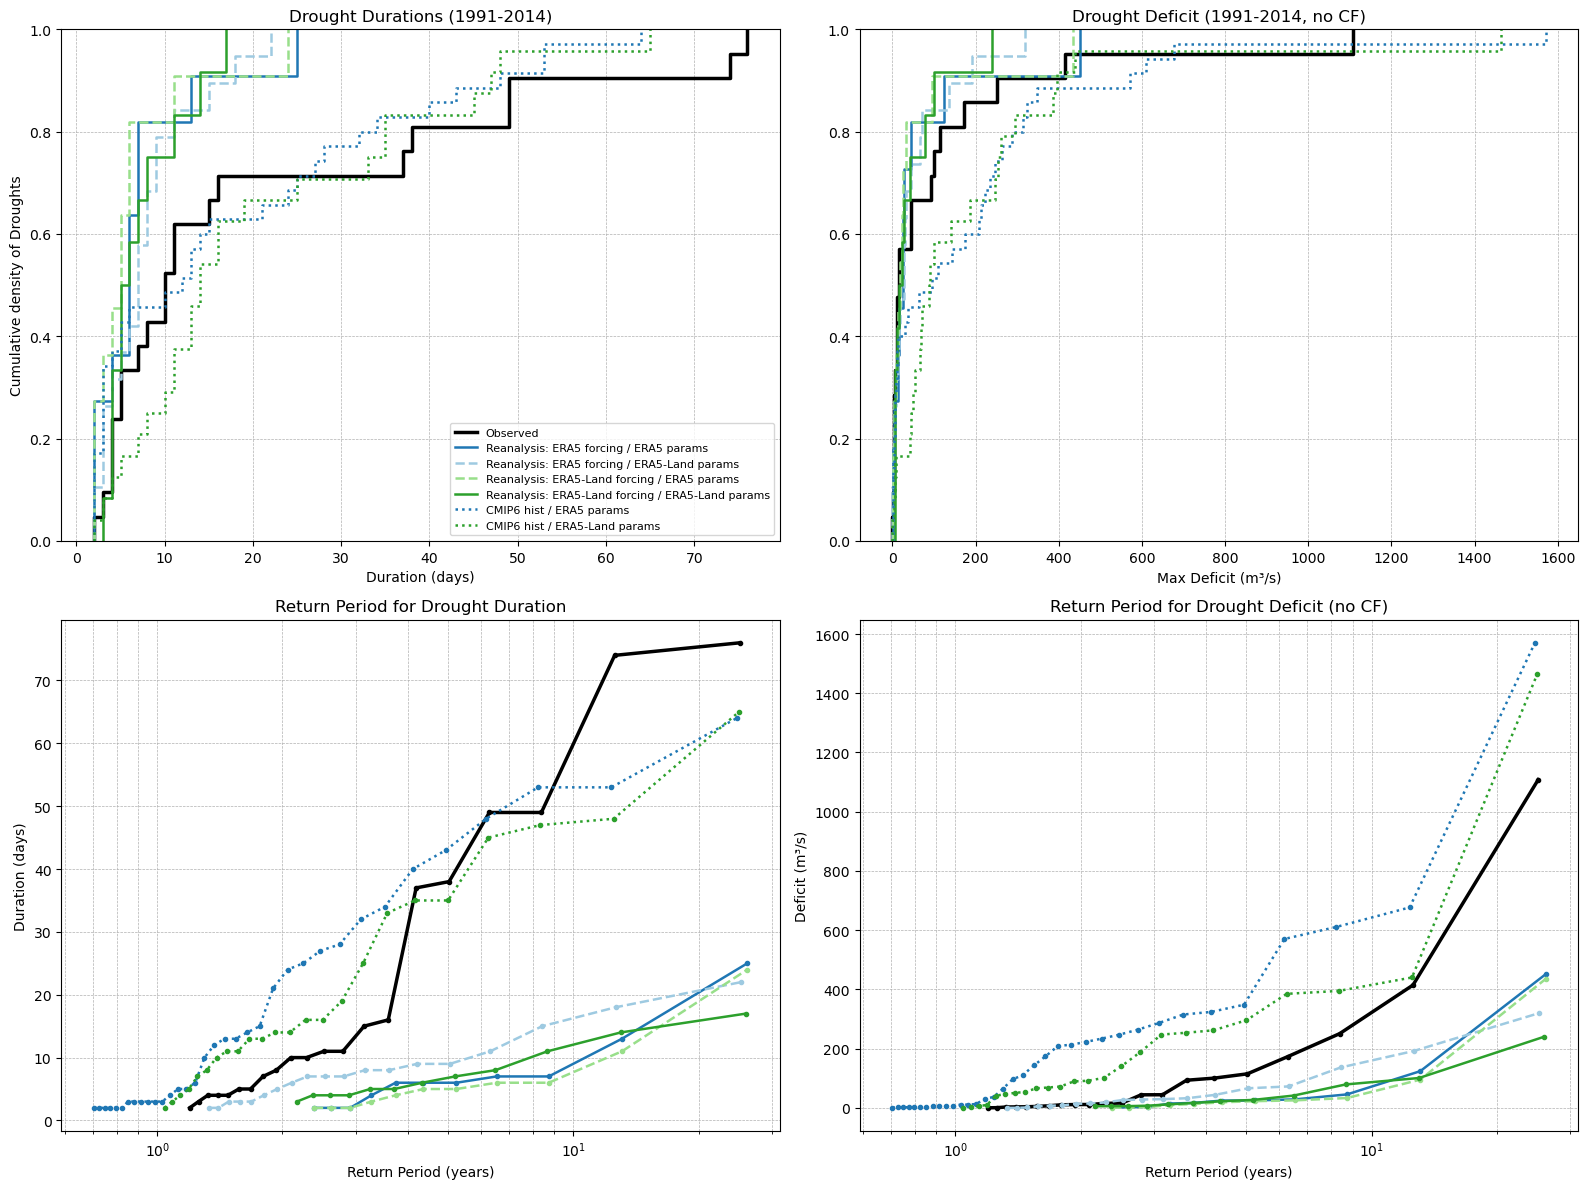

In [29]:
# ADDED (new cell)
# ECDF and return periods of droughts 1991-2014 (raw deficits)
style = {"Observed": dict(color="k", ls="-")}
for key in Q_rea:
    style[f"Reanalysis: {label[key]}"] = dict(color=colors_rea[key], ls="-" if key in matched else "--")
style["CMIP6 hist / ERA5 params"] = dict(color="#1f77b4", ls=":")
style["CMIP6 hist / ERA5-Land params"] = dict(color="#2ca02c", ls=":")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for name, d in droughts_common.items():
    duration = np.sort(d["Duration (days)"].values)
    deficit = np.sort(-d["Max Cumulative Deficit (m3/s)"].values)
    n = len(d)
    F = np.arange(1, n + 1) / (n + 1)
    rp = years_common / (n * (1 - F))
    lw = 2.5 if name == "Observed" else 1.8

    sns.ecdfplot(duration, ax=axes[0, 0], lw=lw, label=name, **style[name])
    sns.ecdfplot(deficit, ax=axes[0, 1], lw=lw, label=name, **style[name])
    axes[1, 0].plot(rp, duration, marker="o", ms=3, lw=lw, label=name, **style[name])
    axes[1, 1].plot(rp, deficit, marker="o", ms=3, lw=lw, label=name, **style[name])

axes[0, 0].set(title="Drought Durations (1991-2014)", xlabel="Duration (days)", ylabel="Cumulative density of Droughts")
axes[0, 1].set(title="Drought Deficit (1991-2014, no CF)", xlabel="Max Deficit (m³/s)", ylabel="")
axes[1, 0].set(title="Return Period for Drought Duration", xlabel="Return Period (years)", ylabel="Duration (days)", xscale="log")
axes[1, 1].set(title="Return Period for Drought Deficit (no CF)", xlabel="Return Period (years)", ylabel="Deficit (m³/s)", xscale="log")

for ax in axes.flat:
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
axes[0, 0].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()